In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')

from matplotlib.pyplot import figure
from matplotlib.lines import Line2D

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)

1 - Understanding the data structure

In [2]:
# reading the data
df = pd.read_csv(
    r'../data/ai_jobs_salaries_clean.csv'
)

print(f'| Rows: {df.shape[0]} | Columns: {df.shape[1]} |')
df.head()

| Rows: 71913 | Columns: 17 |


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


In [3]:
df.dtypes

work_year                  int64
experience_level          object
employment_type           object
job_title                 object
salary                     int64
salary_currency           object
salary_in_usd              int64
employee_residence        object
remote_ratio               int64
company_location          object
company_size              object
experience_level_label    object
employment_type_label     object
work_mode                 object
salary_outlier_flag         bool
role_family               object
isco_group_hint           object
dtype: object

2 - Verifying data distribution

In [4]:
# summary statistic
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,71913.000000,7.191300e+04,71913.000000,71913.000000
mean,2024.425153,1.617102e+05,151161.252625,24.569271
std,0.721198,2.872868e+05,77329.594122,42.917779
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,9.640000e+04,96000.000000,0.000000
50%,2025.000000,1.397000e+05,138750.000000,0.000000
75%,2025.000000,1.922000e+05,190315.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


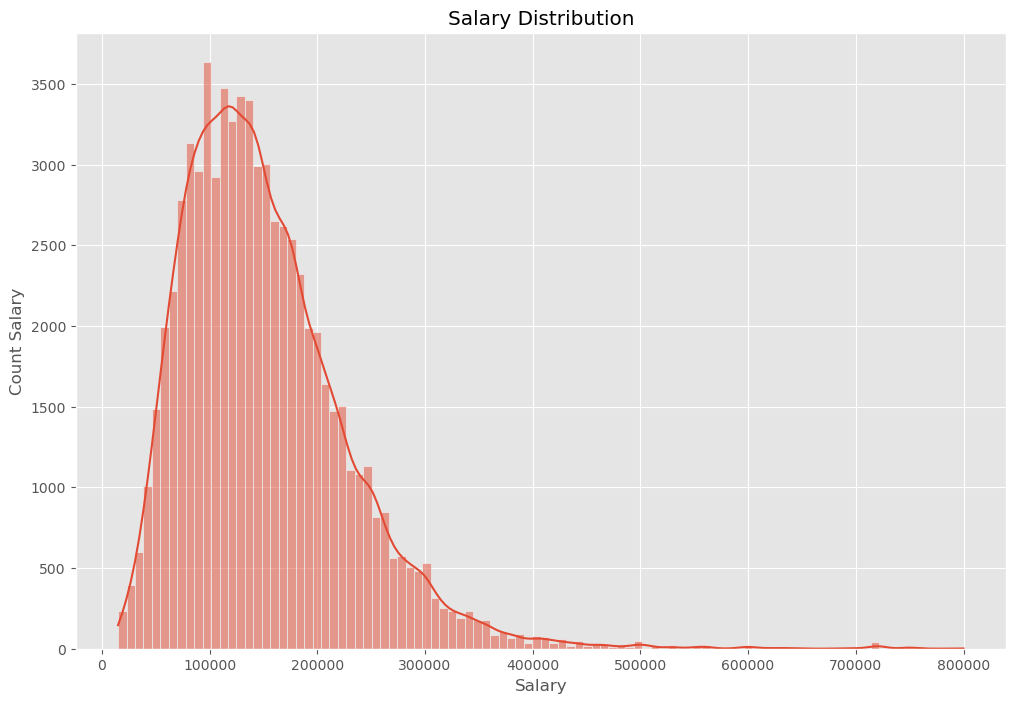

In [5]:
# salary distribution
sns.histplot(
    data = df,
    x = 'salary_in_usd',
    bins = 100,
    kde = True
)

plt.title('Salary Distribution')

plt.ylabel('Count Salary')
plt.xlabel('Salary')

plt.show()

In [6]:
# data distribution across work mode
count_work_modes = df['work_mode'].value_counts()
perc_work_modes = round(df['work_mode'].value_counts(normalize = True) * 100, 1).astype(str) + ' %'

print('-' * 34)
print('| Work Mode | Count | Percentage |')

for i in count_work_modes.index:
    print(f'| {i:<9} | {count_work_modes[i]:<5} | {perc_work_modes[i]:<10} |')

print('-' * 34)

----------------------------------
| Work Mode | Count | Percentage |
| On-site   | 54081 | 75.2 %     |
| Remote    | 17505 | 24.3 %     |
| Hybrid    | 327   | 0.5 %      |
----------------------------------


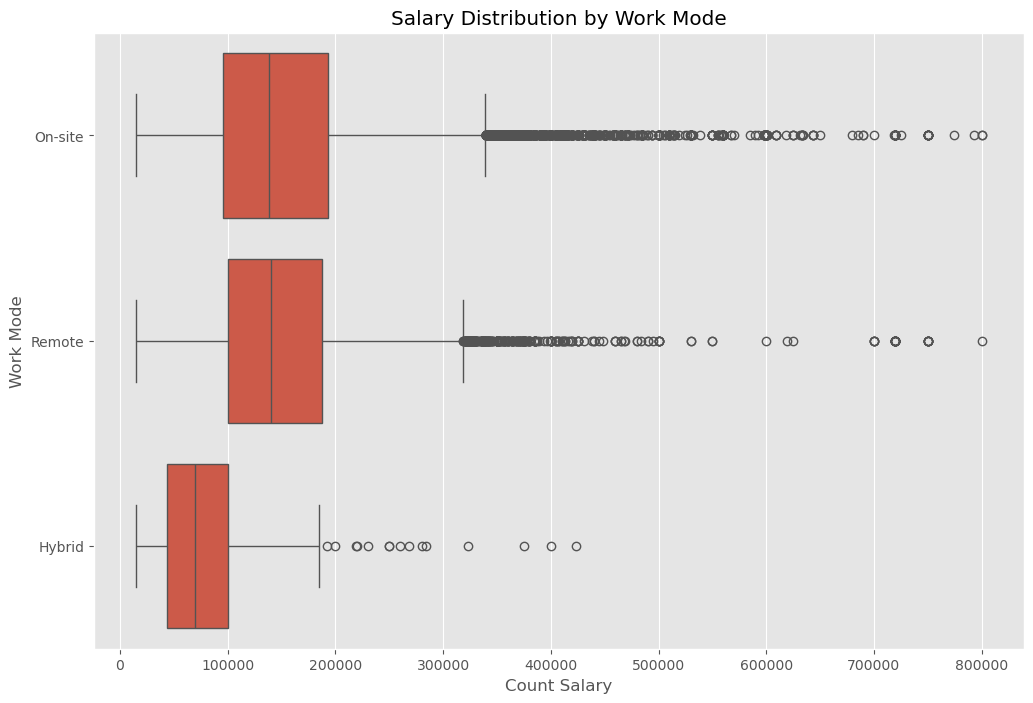

In [7]:
# salary distribution across work mode
sns.boxplot(
    data = df,
    x = 'salary_in_usd',
    y = 'work_mode'
)

plt.title('Salary Distribution by Work Mode')

plt.ylabel('Work Mode')
plt.xlabel('Count Salary')

plt.show()

Handling outliers across remote and on-site modes

-> The test is going to be conducted with extremely flexible and inflexible work modes; for this reason, hybrid mode is not going to be used

In [8]:
# separating work modes (remote and on-site) into datasets
df_onsite = df[
    df['work_mode'] == 'On-site'
]

df_remote = df[
    df['work_mode'] == 'Remote'
]

# finding the 25th percentile of both groups
onsite_25 = np.percentile(df_onsite['salary_in_usd'], 25)
remote_25 = np.percentile(df_remote['salary_in_usd'], 25)

# finding the 75th percentile of both groups
onsite_75 = np.percentile(df_onsite['salary_in_usd'], 75)
remote_75 = np.percentile(df_remote['salary_in_usd'], 75)

# calculating the On-site boundaries
onsite_lb = onsite_25 - ((onsite_75 - onsite_25) * 1.5)
if onsite_lb < 0: onsite_lb = 0 

onsite_ub = onsite_75 + ((onsite_75 - onsite_25) * 1.5)

# calculating the Remote boundaries
remote_lb = remote_25 - ((remote_75 - remote_25) * 1.5)
if remote_lb < 0: remote_lb = 0

remote_ub = remote_75 + ((remote_75 - remote_25) * 1.5)

# print configuration
onsite_iqr_label = f'| On-Site 25th Percentil: {onsite_25:<10} | On-Site 75th Percentil {onsite_75:<10} |'
remote_iqr_label = f'| Remote 25th Percentil:  {remote_25:<10} | Remote 75th Percentil  {remote_75:<10} |'

onsite_bnd_label = f'| On-Site Lower Bound: {onsite_lb:<13} | On-site Uper Bound: {onsite_ub:<13} |'
remote_bnd_label = f'| Remote Lower Bound:  {remote_lb:<13} | Remote Uper Bound:  {remote_ub:<13} |'

print("-" * len(onsite_iqr_label))
print(onsite_iqr_label)
print(remote_iqr_label)
print("-" * len(onsite_iqr_label))
print(onsite_bnd_label)
print(remote_bnd_label)
print("-" * len(onsite_iqr_label))

--------------------------------------------------------------------------
| On-Site 25th Percentil: 95300.0    | On-Site 75th Percentil 192890.0   |
| Remote 25th Percentil:  100000.0   | Remote 75th Percentil  187200.0   |
--------------------------------------------------------------------------
| On-Site Lower Bound: 0             | On-site Uper Bound: 339275.0      |
| Remote Lower Bound:  0             | Remote Uper Bound:  318000.0      |
--------------------------------------------------------------------------


In [9]:
# filtering values within the boundaries range (on-site table)
df_onsite = df_onsite[
    (df_onsite['salary_in_usd'] >= onsite_lb) & (df_onsite['salary_in_usd'] <= onsite_ub)
]

df_onsite.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,52761.000000,5.276100e+04,52761.000000,52761.0
mean,2024.469551,1.529216e+05,145535.609560,0.0
std,0.645615,2.229073e+05,66470.548524,0.0
min,2020.000000,1.440000e+04,15000.000000,0.0
25%,2024.000000,9.450000e+04,94600.000000,0.0
50%,2025.000000,1.369000e+05,136400.000000,0.0
75%,2025.000000,1.885000e+05,187450.000000,0.0
max,2025.000000,1.800000e+07,339250.000000,0.0


In [10]:
# filtering values within the boundaries range (remote table)
df_remote = df_remote[
    (df_remote['salary_in_usd'] >= remote_lb) & (df_remote['salary_in_usd'] <= remote_ub)
]

df_remote.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,17187.000000,1.718700e+04,17187.000000,17187.0
mean,2024.313085,1.589272e+05,144671.441729,100.0
std,0.857680,3.811933e+05,61020.895971,0.0
min,2020.000000,1.400000e+04,15000.000000,100.0
25%,2024.000000,1.000000e+05,99434.000000,100.0
50%,2025.000000,1.400000e+05,139406.000000,100.0
75%,2025.000000,1.854200e+05,184000.000000,100.0
max,2025.000000,3.040000e+07,318000.000000,100.0


In [11]:
# mergering the filtered datasets
df_work_mode = pd.concat(
    [df_onsite, df_remote], ignore_index = True
)

print(f'| Rows: {df_work_mode.shape[0]} | Columns: {df_work_mode.shape[1]} |')
df_work_mode.head()

| Rows: 69948 | Columns: 17 |


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
1,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
2,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Business Intelligence Engineer,180500,USD,180500,US,0,US,M,Senior-level,Full-time,On-site,False,Data Analyst,Business services and administration managers
4,2025,SE,FT,Business Intelligence Engineer,113000,USD,113000,US,0,US,M,Senior-level,Full-time,On-site,False,Data Analyst,Business services and administration managers


In [12]:
# saving the dataset
df_work_mode.to_csv(r'../data/work_mode.csv')

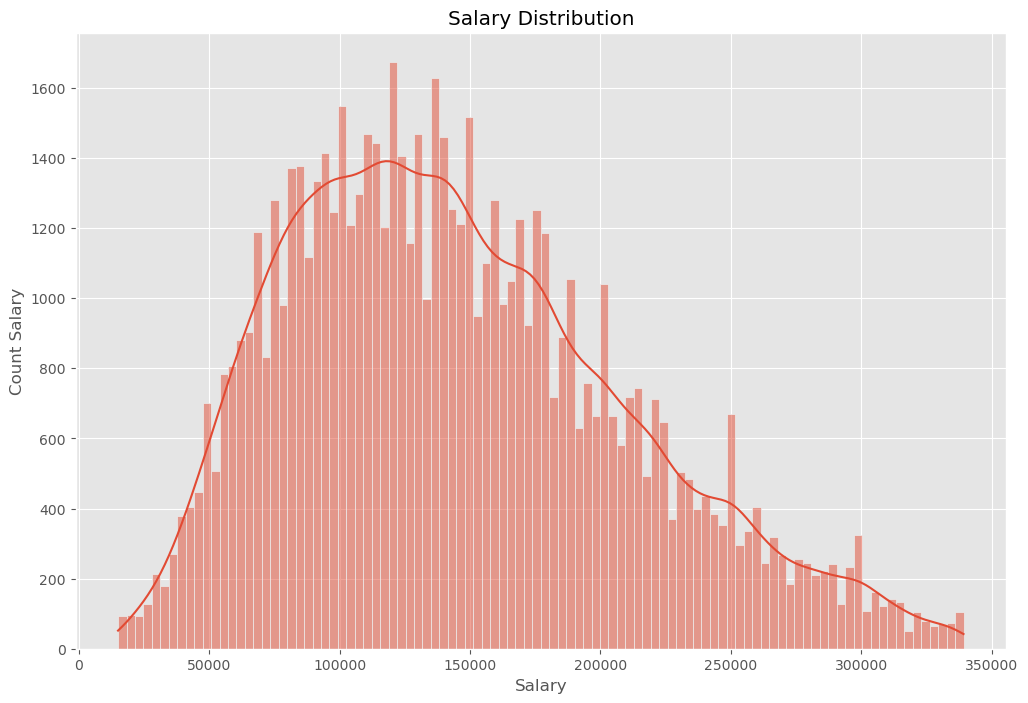

In [13]:
# checking the new data distribution
sns.histplot(
    data = df_work_mode,
    x = 'salary_in_usd',
    bins = 100,
    kde = True
)

plt.title('Salary Distribution')

plt.ylabel('Count Salary')
plt.xlabel('Salary')

plt.show()

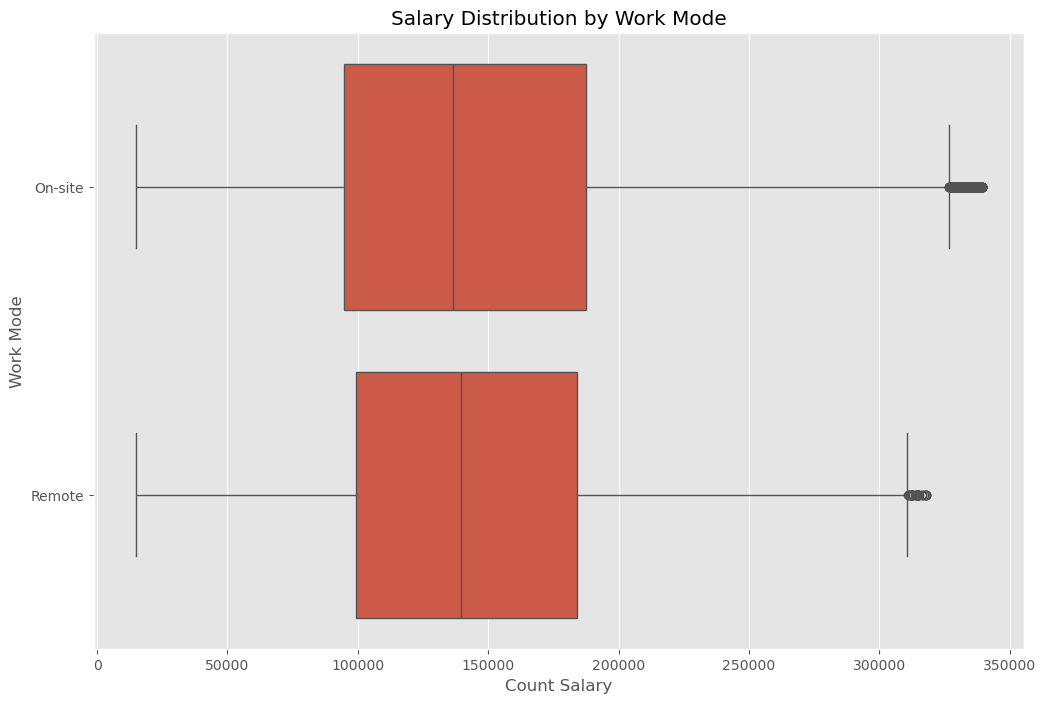

In [14]:
# checking the new salary across work mode distribution
sns.boxplot(
    data = df_work_mode,
    x = 'salary_in_usd',
    y = 'work_mode'
)

plt.title('Salary Distribution by Work Mode')

plt.ylabel('Work Mode')
plt.xlabel('Count Salary')

plt.show()

3 - Examining the data spread (Levene test)

-> Equal variance between groups; therefore, a Welch's t-test is going to be performed

In [15]:
# alpha
alpha = 0.05

# means of both groups
onsite_salary_mean = np.mean(df_onsite['salary_in_usd'])

remote_salary_mean = np.mean(df_remote['salary_in_usd'])

# applying the levene test
levene_stats, levene_p_value = stats.levene(df_onsite['salary_in_usd'], df_remote['salary_in_usd'])

# printing the result

print(f'On-site mean:   {onsite_salary_mean:.2f}')
print(f'Remote mean:    {remote_salary_mean:.2f}')
print(f'Levene P-value: {levene_p_value}')

On-site mean:   145535.61
Remote mean:    144671.44
Levene P-value: 1.3741589446498728e-34


4 - Applying the test

**Experiment 1:** Is there a salary gap between on-site and remote modes?

**Variables:** 
* Salary (USD); 
* Work Mode (Remote and On-site)

**Test Parameters:**
* **Null Hypothesis (H0):** Mean salaries are identical between the work modes
* **Alternative Hypothesis (H1):** Mean salaries are not identical between the work modes
* **Alpha:** 0.05

In [16]:
# applying the welch's test
t_stat, p_value = stats.ttest_ind(df_onsite['salary_in_usd'], df_remote['salary_in_usd'], equal_var = False)

# test result
if p_value < alpha:
    print('Reject the Null Hypothesis (H0) - There is statistically significant between remote and on-site workers salaries')
else:
    print('Fail to reject the Null hypothesis (H0) - There is no statiscally difference to confidently say the true market means are different')

Fail to reject the Null hypothesis (H0) - There is no statiscally difference to confidently say the true market means are different


In [17]:
print(p_value)

0.1148703282372552
